# Task 1: Data Preprocessing

### Task 1.1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt

### Task 1.2: Load the Dataset

In [10]:
df = pd.read_csv(r"C:\Users\lavia\Downloads\Lab 8 - Sheet1.csv")

In [11]:
df.head(10)

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Overcast,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   No           50 non-null     int64 
 1   Outlook      50 non-null     object
 2   Temperature  50 non-null     object
 3   Humidity     50 non-null     object
 4   Wind         50 non-null     object
 5   Play Tennis  50 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.5+ KB


In [13]:
print(df.shape)

(50, 6)


### Task 1.3: Remove the Serial Number Column

In [14]:
df = df.drop("No", axis=1)
df.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


### Task 1.4: Separate Features and Target Variable

Input Features:

Outlook, 
Temperature, 
Humidity, 
Wind

Target Variable:

Play Tennis

In [15]:
X = df.drop("Play Tennis", axis=1)

y = df["Play Tennis"]

In [16]:
X.head()

,Outlook,Temperature,Humidity,Wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak


In [17]:
y.head()

0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: object

### Task 1.5: Encode the Categorical Data

In [18]:
label_encoders = {}

for column in X.columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    label_encoders[column] = encoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [19]:
print(X.head())

print(y[:10])

   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1
[0 0 1 1 1 0 1 0 1 1]


# Task 2: Dataset Partitioning

Divide the dataset into 80% training data and 20% testing data.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 40
Testing Samples  : 10


# Task 3: Naive Bayes Model Training & Evaluation

### Task 3.1: Train the Categorical Naive Bayes Model

In [22]:
nb_model = CategoricalNB()

nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


### Task 3.2: Predict the Test Dataset

In [23]:
y_pred = nb_model.predict(X_test)

### Task 3.3: Calculate Model Accuracy

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", round(accuracy*100,2),"%")

Model Accuracy : 80.0 %


### Task 3.4: Display the Confusion Matrix

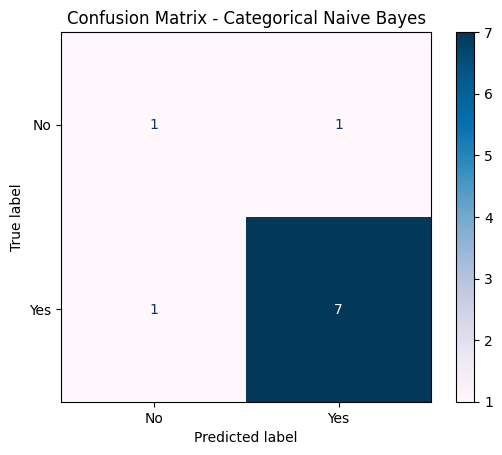

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)
disp.plot(cmap="PuBu")
plt.title("Confusion Matrix - Categorical Naive Bayes")
plt.show()

### Conclusion

The confusion matrix shows that the Categorical Naive Bayes classifier correctly classified 8 out of 10 test instances, achieving an accuracy of 80%. The model correctly identified 7 "Yes" instances and 1 "No" instance, while making 2 misclassifications. The darker blue cell represents the highest number of correct predictions, indicating that most test samples belonged to the "Yes" class and were classified correctly.

### Task 3.5: Display the Classification Report

In [27]:
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.88      0.88      0.88         8

    accuracy                           0.80        10
   macro avg       0.69      0.69      0.69        10
weighted avg       0.80      0.80      0.80        10



### Conclusion

The Categorical Naive Bayes classifier achieved an overall accuracy of 80% on the test dataset. It performed better in predicting the "Yes" class, obtaining a precision, recall, and F1-score of 0.88, while the "No" class achieved 0.50 for all three metrics due to the smaller number of samples. The weighted average F1-score of 0.80 indicates that the classifier performed well overall, although its performance on the minority class was comparatively lower.

# Task 4: Single-Sample Inference

Predict whether a person will play tennis under the following weather conditions.

### Task 4.1: Create the Sample

In [28]:
sample = pd.DataFrame({
    "Outlook":["Sunny"],
    "Temperature":["Cool"],
    "Humidity":["High"],
    "Wind":["Strong"]
})

### Task 4.2: Encode the Sample

In [29]:
for column in sample.columns:
    sample[column] = label_encoders[column].transform(sample[column])

### Task 4.3: Predict the Class Label

In [30]:
prediction = nb_model.predict(sample)

predicted_label = target_encoder.inverse_transform(prediction)

print("Predicted Class :")

print(predicted_label[0])

Predicted Class :
No


### Task 4.4: Display the Class Probabilities

In [31]:
probability = nb_model.predict_proba(sample)

print("Class Probabilities:")

print(probability)

Class Probabilities:
[[0.92560203 0.07439797]]


### Conclusion

For the given weather conditions (Sunny, Cool, High Humidity, Strong Wind), the Categorical Naive Bayes classifier predicted that the person would not play tennis ("No"). The model assigned a probability of approximately 92.56% to the "No" class and 7.44% to the "Yes" class, indicating a high level of confidence in its prediction.

# Task 5: Model Comparison

Train and compare the following classifiers:

Decision Tree, 
Logistic Regression, 
Support Vector Machine (SVM)

### Task 5.1: Train the Decision Tree Classifier

In [32]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)

### Task 5.2: Train the Logistic Regression Classifier

In [34]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
lr_prediction = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_prediction)

### Task 5.3: Train the SVM Classifier

In [36]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
svm_prediction = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_prediction)

### Task 5.4: Predict the Same Sample Using All Models

Decision Tree

In [38]:
dt_label = target_encoder.inverse_transform(
    dt_model.predict(sample)
)

dt_probability = dt_model.predict_proba(sample)

Logistic Regression

In [39]:
lr_label = target_encoder.inverse_transform(
    lr_model.predict(sample)
)

lr_probability = lr_model.predict_proba(sample)

SVM

In [40]:
svm_label = target_encoder.inverse_transform(
    svm_model.predict(sample)
)

svm_probability = svm_model.predict_proba(sample)

### Task 5.5: Display the Comparison Table

In [41]:
comparison = pd.DataFrame({
    "Model":[
        "Categorical Naive Bayes",
        "Decision Tree",
        "Logistic Regression",
        "SVM"
    ],
    "Test Accuracy":[
        accuracy,
        dt_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    "Prediction":[
        predicted_label[0],
        dt_label[0],
        lr_label[0],
        svm_label[0]
    ]
})

print(comparison)

                     Model  Test Accuracy Prediction
0  Categorical Naive Bayes            0.8         No
1            Decision Tree            0.8         No
2      Logistic Regression            0.4         No
3                      SVM            0.7         No


### Task 5.6: Accuracy Comparison Graph

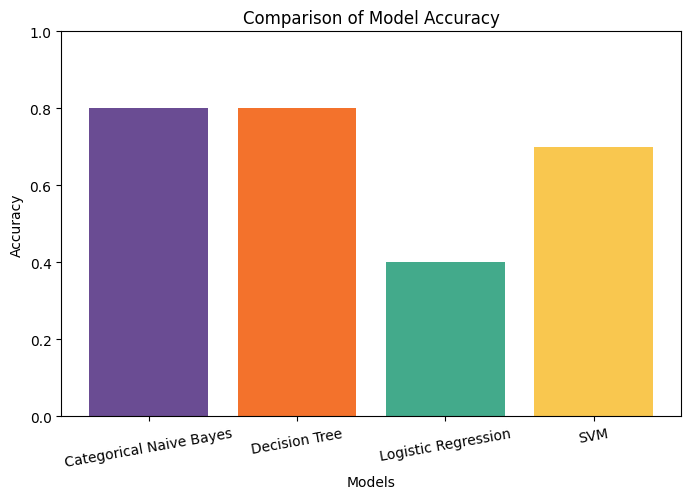

In [42]:
plt.figure(figsize=(8,5))

colors = [
    "#6A4C93",
    "#F3722C",
    "#43AA8B",
    "#F9C74F"
]

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"],
    color=colors
)

plt.title("Comparison of Model Accuracy")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.xticks(rotation=10)

plt.show()

### Conclusion

The accuracy comparison graph shows that the Categorical Naive Bayes and Decision Tree classifiers achieved the highest test accuracy of 80%. The SVM classifier achieved an accuracy of 70%, while Logistic Regression performed the lowest with 40% accuracy. These results indicate that Categorical Naive Bayes and Decision Tree are better suited for this categorical Play Tennis dataset, whereas Logistic Regression was less effective in capturing the relationships among the categorical features.

# Analysis Report

The four classification models produced different performance results because each algorithm uses a different approach to learning patterns from the training data. Categorical Naive Bayes assumes conditional independence among features, Decision Tree creates rule-based splits, Logistic Regression models a linear decision boundary, and SVM identifies an optimal separating hyperplane. Although all models predicted "No" for the given weather conditions, their accuracy differed due to variations in how effectively they captured the relationships within the categorical dataset. The probability values also differ because each classifier estimates prediction confidence using its own underlying mathematical model.